# F1 Exploration — Promo / Markdown Separation

Answer 5 questions to inform feature F1 and pick 2-3 showcase SKUs.

Run cells top to bottom.

## Cell 1 — Imports & file paths

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

DATA = 'data/'
SALES_CSV   = DATA + 'POP_SalesTransactionHistory.csv'
INV_XLSX    = DATA + 'POP_InventorySnapshot.xlsx'
ITEM_XLSX   = DATA + 'POP_ItemSpecMaster.xlsx'
VENDOR_XLSX = DATA + 'POP_VendorMaster.xlsx'
PO_XLSX     = DATA + 'POP_PurchaseOrderHistory.XLSX'
CB_XLSX     = DATA + 'POP_ChargeBack_Deductions_Penalties_Freight.xlsx'

## Cell 2 — Load all core files

In [7]:
sales = pd.read_csv(SALES_CSV, parse_dates=['DOCDATE'], low_memory=False)

inv = pd.concat([
    pd.read_excel(INV_XLSX, sheet_name='Site 1 - SF').assign(DC='SF'),
    pd.read_excel(INV_XLSX, sheet_name='Site 2 - NJ').assign(DC='NJ'),
    pd.read_excel(INV_XLSX, sheet_name='Site 3 - LA').assign(DC='LA'),
], ignore_index=True)

items   = pd.read_excel(ITEM_XLSX, sheet_name='Item Spec Master')
vendors = pd.read_excel(VENDOR_XLSX, sheet_name='Supplier Master')
pos     = pd.read_excel(PO_XLSX, sheet_name='PO Order History 2023-2025')
cb      = pd.read_excel(CB_XLSX, sheet_name='Data - Deductions & Cause Code')

print('sales :', sales.shape, '  date range:', sales['DOCDATE'].min(), '->', sales['DOCDATE'].max())
print('inv   :', inv.shape)
print('items :', items.shape)
print('vendors:', vendors.shape)
print('pos   :', pos.shape)
print('cb    :', cb.shape)

sales : (236818, 23)   date range: 2023-01-03 00:00:00 -> 2026-04-13 00:00:00
inv   : (219, 5)
items : (65, 15)
vendors: (73, 17)
pos   : (5281, 16)
cb    : (18804, 13)


## Cell 3 — Q1: What cause codes exist in chargebacks?

Looking for: codes that mean TPR / promo. Note the exact code strings in a comment.

In [8]:
print('--- Top cause codes by count ---')
print(cb['Cause Code'].value_counts().head(30))

print('\n--- Unique code/description pairs ---')
pairs = cb[['Cause Code','Cause Code Desc']].drop_duplicates().sort_values('Cause Code')
print(pairs.to_string())

print('\n--- Rows whose description mentions TPR / promo / markdown / discount ---')
promo_like = pairs[pairs['Cause Code Desc'].str.contains('TPR|promo|markdown|price reduction|discount', case=False, na=False)]
print(promo_like.to_string())

--- Top cause codes by count ---
Cause Code
CRED08      4286
CRED03      4113
CRED06      3202
CRED05      1645
CRED07      1193
CRED09       774
CRED02       571
CRED11-O     480
CRED12       451
CRED11-F     295
CRED04       259
CRED19       253
CRED99       186
CRED13       158
CRED10-D     150
CRED-PRO     130
CRED21       101
CRED10        96
CRED20        86
CRED01        79
CRED15        65
CRED18        58
CRED-TRF      55
CRED-DIS      53
CRED-COM      20
CRED17        10
CRED-FUL      10
CRED-STO      10
CRED16         9
CRED-SDT       3
Name: count, dtype: int64

--- Unique code/description pairs ---
      Cause Code                                              Cause Code Desc
1004    CRED-COM                                                   Commission
1214    CRED-DIS                                                    Discounts
1209    CRED-DMG                                                      Damages
1007    CRED-FUL                                               Fulfil

## Cell 4 — Q2: Do chargebacks link to sales via SOP Number?

In [9]:
# Filter chargebacks to the promo-like codes. Update the regex if Cell 3 shows other TPR indicators.
tpr = cb[cb['Cause Code Desc'].str.contains('TPR|promo|price reduction', case=False, na=False)]
print(f'TPR-ish chargeback rows: {len(tpr)}')
print(tpr[['SOP Number','Document Date','Cause Code','Cause Code Desc','Item Description','Extended Price']].head(10).to_string())

tpr_sops   = set(tpr['SOP Number'].dropna().astype(str))
sales_sops = set(sales['SOPNUMBE'].dropna().astype(str))
overlap = tpr_sops & sales_sops
print(f'\nTPR SOPs that match a sales SOPNUMBE: {len(overlap)} / {len(tpr_sops)}')

if overlap:
    sample_sop = next(iter(overlap))
    print(f'\nExample matched SOP {sample_sop}:')
    print('-- sales rows --')
    print(sales[sales['SOPNUMBE'].astype(str)==sample_sop][['DOCDATE','ITEMNMBR','QUANTITY_adj','Unit_Price_adj','Customer Type']])
    print('-- chargeback rows --')
    print(tpr[tpr['SOP Number'].astype(str)==sample_sop][['Document Date','Cause Code Desc','Item Description','Extended Price']])

TPR-ish chargeback rows: 6868
    SOP Number Document Date Cause Code                                             Cause Code Desc                                  Item Description  Extended Price
0      1363759    2024-05-30     CRED03                                     Retailer- TPR Scan Down                TBZ - 02/22 Repayment on wrong TPR        33381.00
23    RTN52001    2023-10-25     CRED03                                     Retailer- TPR Scan Down    TBZ - 04/23 Tiger Balm $1.5 Price Cut Scanback        49033.50
24    RTN52001    2023-10-25     CRED03                                     Retailer- TPR Scan Down    TBZ - 04/23 Tiger Balm $1.5 Price Cut Scanback          102.00
33    RTN52014    2023-10-26     CRED03                                     Retailer- TPR Scan Down   TBZ - 02/22 To Collect Funding Due for TB Price        48027.00
43    RTN52018    2023-10-26     CRED02  Retailer TPR/Insertion/Admin Fee/Accrual/Adv/Promo Funding  TBZ - 07/23 TB Extra/Ultra $1.50 Price 

## Cell 5 — Q3: Unit price distribution for a busy SKU

Looking for: a dominant 'normal price' cluster plus a tail at lower prices = markdowns.

Top 5 busiest SKUs:
ITEMNMBR
T-32206    21231
T-31510    20101
T-22010    17169
F-04111    14939
F-04112    11186
Name: count, dtype: int64

Unit_Price_adj stats for T-32206:
count    21231.000000
mean         3.534456
std          0.759611
min          0.000000
25%          3.225625
50%          3.482197
75%          3.861429
max         25.575000
Name: Unit_Price_adj, dtype: float64


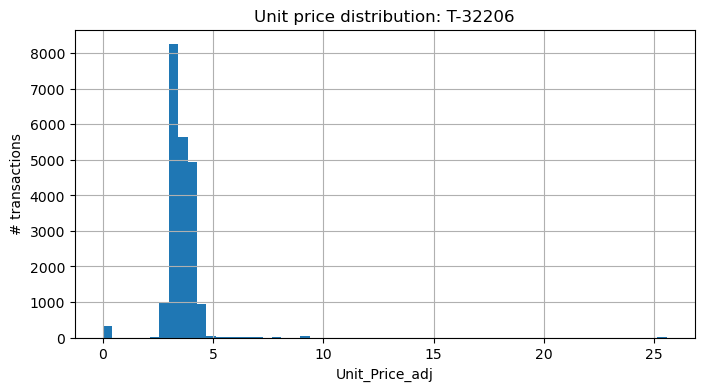

In [10]:
top5 = sales['ITEMNMBR'].value_counts().head(5)
print('Top 5 busiest SKUs:')
print(top5)

top_sku = top5.index[0]
s = sales[sales['ITEMNMBR']==top_sku]
print(f'\nUnit_Price_adj stats for {top_sku}:')
print(s['Unit_Price_adj'].describe())

fig, ax = plt.subplots(figsize=(8,4))
s['Unit_Price_adj'].hist(bins=60, ax=ax)
ax.set_title(f'Unit price distribution: {top_sku}')
ax.set_xlabel('Unit_Price_adj'); ax.set_ylabel('# transactions')
plt.show()

## Cell 6 — Q4: What's the channel column?

In [11]:
print('--- Customer Type ---')
print(sales['Customer Type'].value_counts(dropna=False))
print('\n--- Product Type ---')
print(sales['Product Type'].value_counts(dropna=False))
print('\n--- LOCNCODE (shipping DC) ---')
print(sales['LOCNCODE'].value_counts(dropna=False))
print('\n--- SOP TYPE (invoice vs return) ---')
print(sales['SOP TYPE'].value_counts(dropna=False))

--- Customer Type ---
Customer Type
Mass               33493
Supermarket        32747
Chain              27780
Herbal             25644
Dist-HF            16094
                   ...  
New Hing Wongs         1
Airam Internati        1
T C Pine Garden        1
V Multi Service        1
Little Neck Sup        1
Name: count, Length: 181, dtype: int64

--- Product Type ---
Product Type
OTC           77601
Chews         67531
Teabags       40307
Choco-Evdy    17568
Candy          9794
AGBag          8892
Cooky-Evdy     4847
InstBev        4635
Grocery        4350
Choco-Gift      803
NaN             490
Name: count, dtype: int64

--- LOCNCODE (shipping DC) ---
LOCNCODE
2     111068
1      71720
3      51851
ZD      1320
E1       468
W        212
U        135
L         44
Name: count, dtype: int64

--- SOP TYPE (invoice vs return) ---
SOP TYPE
Invoice    235137
Return       1681
Name: count, dtype: int64


## Cell 7 — Q5: Pick 2-3 showcase SKUs

Criteria: lots of lines, >=2 channels, has TPR activity, ideally mix of fast/slow turning.

In [12]:
sku_stats = (sales[sales['SOP TYPE']=='Invoice']
             .groupby('ITEMNMBR')
             .agg(lines=('SOPNUMBE','count'),
                  channels=('Customer Type','nunique'),
                  units=('QUANTITY_adj','sum'),
                  revenue=('XTNDPRCE_adj','sum'),
                  first_sale=('DOCDATE','min'),
                  last_sale=('DOCDATE','max'))
             .sort_values('lines', ascending=False))

desc_map = sales.drop_duplicates('ITEMNMBR').set_index('ITEMNMBR')['ITEMDESC']
sku_stats['desc'] = desc_map

tpr_descs = set(tpr['Item Description'].dropna())
sku_stats['has_tpr'] = sku_stats['desc'].isin(tpr_descs)

print('Top 20 candidates:')
print(sku_stats[['desc','lines','channels','units','revenue','has_tpr']].head(20).to_string())

Top 20 candidates:
                                                       desc  lines  channels   units      revenue  has_tpr
ITEMNMBR                                                                                                  
T-32206                          Tiger Balm Patch Warm (MM)  21231        56  448083  22985078.59    False
T-31510                            Tiger Balm 18g, Ultra/St  20101        47  779826  36618774.11    False
T-22010                      Tiger Balm 18g Red, Ext/St(MM)  17169        72  135765  20522243.77    False
F-04111            POP Ginger Chews Original 4 oz (12ct/cs)  14867        93  978964   9169803.81    False
F-04112               POP Ginger Chews Lemon 4 oz (12ct/cs)  11061        79  519913   4674975.69    False
F-04114               POP Ginger Chews Mango 4 oz (12ct/cs)   8932        71  365027   2890678.22    False
F-04117        POP Ginger Chews Blood Orange 4 oz (12ct/cs)   7395        72  255757   1790967.47    False
T-31541           

## Cell 8 — Quick sanity: weekly sales for top 3 candidates

First visual feel for seasonality / volatility.

Showcase candidates: ['T-32206', 'T-31510', 'T-22010']


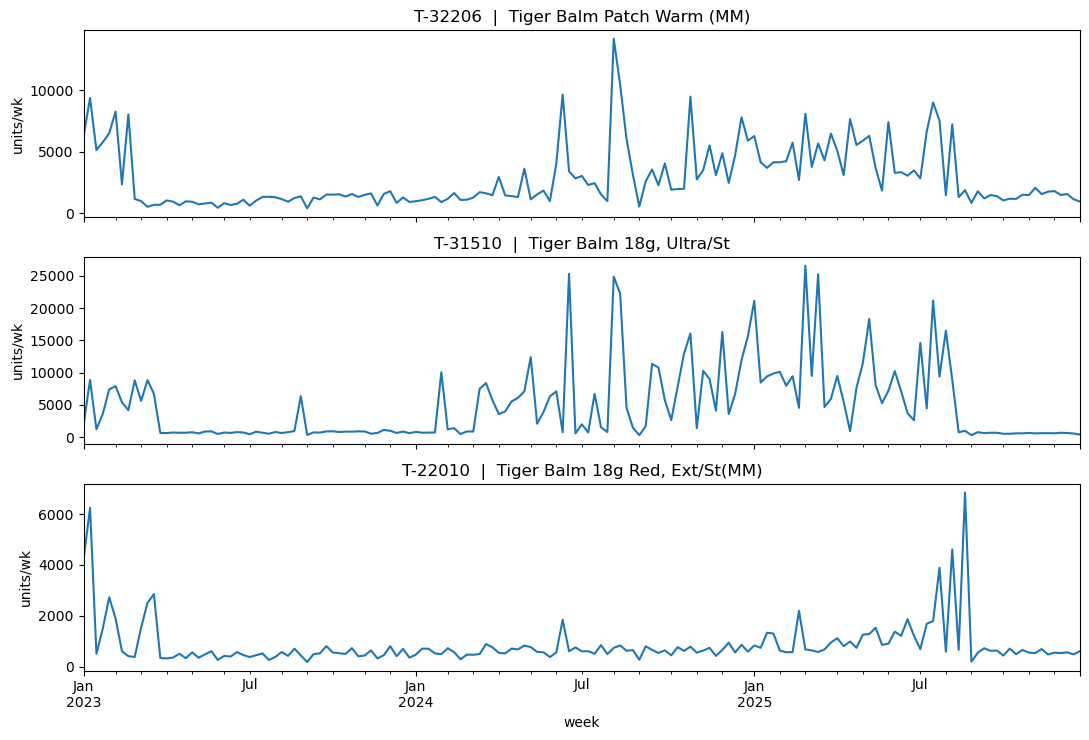

In [13]:
candidates = sku_stats[(sku_stats['channels']>=2) & (sku_stats['has_tpr'])].head(3).index.tolist()
if len(candidates) < 3:
    candidates = sku_stats.head(3).index.tolist()
print('Showcase candidates:', candidates)

inv_sales = sales[sales['SOP TYPE']=='Invoice'].copy()
inv_sales['week'] = inv_sales['DOCDATE'].dt.to_period('W').dt.start_time

fig, axes = plt.subplots(len(candidates), 1, figsize=(11, 2.5*len(candidates)), sharex=True)
if len(candidates)==1: axes=[axes]
for ax, sku in zip(axes, candidates):
    w = inv_sales[inv_sales['ITEMNMBR']==sku].groupby('week')['QUANTITY_adj'].sum()
    w.plot(ax=ax)
    ax.set_title(f'{sku}  |  {str(desc_map.get(sku, ""))[:60]}')
    ax.set_ylabel('units/wk')
plt.tight_layout(); plt.show()

## What to do after running

1. Copy exact TPR cause-code strings from Cell 3 → into a comment at the top of this notebook.
2. Confirm Cell 4 shows real SOP overlap between chargebacks and sales (ideally >100).
3. Look at Cell 5 histogram — is there a clear normal-price peak + lower-price tail?
4. Confirm Cell 6 shows `Customer Type` mapping cleanly to distinct channels.
5. Pick 2-3 SKU numbers from Cell 7/8. Save to `showcase_skus.md`.

Then paste the outputs back to me and we design F1 logic.

## Cell 9 — Q6: Revised linkage — Customer + Brand window (SOP join failed)

Findings from Cells 3 & 4: TPR codes are `CRED02/03/04/05/15/10-D/-PRO/-DIS`. SOP Number does NOT join (chargebacks use RTN# credit memos). Instead we'll join on **Customer Number + Brand + Date window**.

In [14]:
tpr_codes = ['CRED02','CRED03','CRED04','CRED05','CRED-PRO','CRED15','CRED10-D','CRED-DIS','CRED19']
tpr = cb[cb['Cause Code'].isin(tpr_codes)].copy()
print(f'TPR/promo/markdown rows: {len(tpr)}')

# Customer join check
tpr_custs  = set(tpr['Customer Number'].dropna().astype(str))
sales_custs = set(sales['CUSTNMBR'].dropna().astype(str))
print(f'TPR customers present in sales: {len(tpr_custs & sales_custs)} / {len(tpr_custs)}')

# Extract brand from description
BRANDS = ['tiger balm','ginger chew','ferrero','ricola','kwan loong','ginseng','kjeldsens',
          'nutella','totole','bee & flower','am gsg','pop ginger']
def extract_brand(desc):
    if pd.isna(desc): return None
    d = str(desc).lower()
    for b in BRANDS:
        if b in d: return b
    return None
tpr['brand'] = tpr['Item Description'].apply(extract_brand)
print('\nBrand extracted from TPR descriptions:')
print(tpr['brand'].value_counts(dropna=False))

# Sample: Tiger Balm TPR timeline for one customer
sample_cust = tpr[tpr['brand']=='tiger balm']['Customer Number'].value_counts().index[0]
print(f'\nTop Tiger Balm TPR customer: {sample_cust}')
print(tpr[(tpr['brand']=='tiger balm') & (tpr['Customer Number']==sample_cust)]
      [['Document Date','Cause Code','Cause Code Desc','Item Description','Extended Price']]
      .sort_values('Document Date').head(15).to_string())

TPR/promo/markdown rows: 7239
TPR customers present in sales: 103 / 107

Brand extracted from TPR descriptions:
brand
None            5416
ginger chew     1029
tiger balm       614
am gsg           103
ginseng           76
bee & flower       1
Name: count, dtype: int64

Top Tiger Balm TPR customer: MWA600A
      Document Date Cause Code          Cause Code Desc                           Item Description  Extended Price
11033    2023-12-27     CRED03  Retailer- TPR Scan Down  TBZ - 03/23 Tiger Balm scan billback (P8)           16.84
11045    2023-12-27     CRED03  Retailer- TPR Scan Down  TBZ - 08/23 Tiger Balm scan billback (P8)           11.57
11044    2023-12-27     CRED03  Retailer- TPR Scan Down  TBZ - 08/23 Tiger Balm scan billback (P8)            2.10
11043    2023-12-27     CRED03  Retailer- TPR Scan Down  TBZ - 08/23 Tiger Balm scan billback (P8)         1175.08
11041    2023-12-27     CRED03  Retailer- TPR Scan Down  TBZ - 07/23 Tiger Balm scan billback (P8)           27.35
11

In [18]:
tpr.head(5)

,Location Code,Salesperson ID,Customer Number,City from Sales Transaction,State from Sales Transaction,SOP Type,SOP Number,Customer PO Number,Document Date,Cause Code,Cause Code Desc,Item Description,Extended Price,brand,promo_ym,doc_ym
0,1,HOUSE,MRE800A,NaN,NaN,Invoice,1363759,NaN,2024-05-30,CRED03,Retailer- TPR Scan Down,TBZ - 02/22 Repayment on wrong TPR,33381.0,None,2022-02,2024-05
23,1,HOUSE,MRE800A,NaN,NaN,Return,RTN52001,NaN,2023-10-25,CRED03,Retailer- TPR Scan Down,TBZ - 04/23 Tiger Balm $1.5 Price Cut Scanback,49033.5,tiger balm,2023-04,2023-10
24,1,HOUSE,MRE800A,NaN,NaN,Return,RTN52001,NaN,2023-10-25,CRED03,Retailer- TPR Scan Down,TBZ - 04/23 Tiger Balm $1.5 Price Cut Scanback,102.0,tiger balm,2023-04,2023-10
33,1,HOUSE,MRE800A,NaN,NaN,Return,RTN52014,NaN,2023-10-26,CRED03,Retailer- TPR Scan Down,TBZ - 02/22 To Collect Funding Due for TB Price,48027.0,None,2022-02,2023-10
43,1,HOUSE,MRE800A,NaN,NaN,Return,RTN52018,NaN,2023-10-26,CRED02,Retailer TPR/Insertion/Admin Fee/Accrual/Adv/P...,TBZ - 07/23 TB Extra/Ultra $1.50 Price Cut Admin,15000.0,None,2023-07,2023-10


## Cell 10 — Q7: Price-anomaly fallback signal

For each SKU, compute median unit price. Flag transactions with unit price < 0.85× median as markdowns.

In [15]:
invoices = sales[sales['SOP TYPE']=='Invoice'].copy()
invoices = invoices[invoices['Unit_Price_adj'] > 0]  # drop zero-price (free goods)
sku_median = invoices.groupby('ITEMNMBR')['Unit_Price_adj'].median().rename('median_price')
invoices = invoices.merge(sku_median, left_on='ITEMNMBR', right_index=True)
invoices['price_ratio'] = invoices['Unit_Price_adj'] / invoices['median_price']
invoices['markdown_by_price'] = invoices['price_ratio'] < 0.85

print(f'Total invoice lines: {len(invoices)}')
print(f'Flagged as markdown by price: {invoices["markdown_by_price"].sum()} ({invoices["markdown_by_price"].mean()*100:.1f}%)')

# Check for 3 top SKUs
for sku in ['T-32206','F-04111','T-22010']:
    s = invoices[invoices['ITEMNMBR']==sku]
    if len(s)==0: continue
    md = s['markdown_by_price'].sum()
    print(f'  {sku}: {len(s)} lines, {md} markdown ({md/len(s)*100:.1f}%), median={s["median_price"].iloc[0]:.2f}')

Total invoice lines: 227494
Flagged as markdown by price: 36374 (16.0%)
  T-32206: 20893 lines, 1008 markdown (4.8%), median=3.50
  F-04111: 14344 lines, 1881 markdown (13.1%), median=1.33
  T-22010: 16953 lines, 3090 markdown (18.2%), median=4.20


## Cell 11 — Build promo calendar (Customer × Brand × Year-Month)

Extract `MM/YY` from chargeback descriptions (e.g. `"TBZ - 03/23 Tiger Balm scan billback"` → March 2023). The chargeback's own `Document Date` is often months after the actual promo, so we use the embedded date. Result: a lookup table of which (customer, brand, month) combos were on promo.

In [16]:
import re

# Extract MM/YY from description. Covers "03/23", "12/24", etc.
MMYY = re.compile(r'(\b(0[1-9]|1[0-2])/(2[0-9])\b)')
def extract_promo_ym(desc):
    if pd.isna(desc): return None
    m = MMYY.search(str(desc))
    if not m: return None
    mm, yy = m.group(2), m.group(3)
    return pd.Period(f'20{yy}-{mm}', freq='M')

tpr['promo_ym'] = tpr['Item Description'].apply(extract_promo_ym)
# Fallback: if no MM/YY in description, use Document Date's month (less accurate but better than nothing)
tpr['doc_ym'] = pd.to_datetime(tpr['Document Date']).dt.to_period('M')
tpr['promo_ym'] = tpr['promo_ym'].fillna(tpr['doc_ym'])

print('Rows with MM/YY extracted from description:', tpr['Item Description'].apply(extract_promo_ym).notna().sum())
print('Rows falling back to Document Date month    :', tpr['Item Description'].apply(extract_promo_ym).isna().sum())

# Build the promo calendar: unique (Customer, Brand, YearMonth)
promo_cal = (tpr.dropna(subset=['Customer Number','brand','promo_ym'])
                 [['Customer Number','brand','promo_ym']]
                 .drop_duplicates()
                 .reset_index(drop=True))
promo_cal['Customer Number'] = promo_cal['Customer Number'].astype(str)
print(f'\nPromo calendar rows: {len(promo_cal)}')
print('\nPromo-months per brand:')
print(promo_cal.groupby('brand')['promo_ym'].nunique().sort_values(ascending=False))
print('\nSample:')
print(promo_cal.sort_values(['brand','Customer Number','promo_ym']).head(15).to_string(index=False))

Rows with MM/YY extracted from description: 7026
Rows falling back to Document Date month    : 213

Promo calendar rows: 637

Promo-months per brand:
brand
ginger chew     42
tiger balm      38
ginseng         25
am gsg          11
bee & flower     1
Name: promo_ym, dtype: int64

Sample:
Customer Number  brand promo_ym
        MCO222A am gsg  2023-11
        MCO222A am gsg  2023-12
        MCO222A am gsg  2024-01
        MCO222A am gsg  2024-02
        MCO222A am gsg  2024-03
        MCO222A am gsg  2024-10
        MCO222A am gsg  2024-11
        MCO222A am gsg  2024-12
        MCO222A am gsg  2025-01
        MCO346A am gsg  2024-01
        MCO346A am gsg  2024-02
        MCO346A am gsg  2024-11
        MCO346A am gsg  2024-12
        MCO346A am gsg  2025-01
        MCO346A am gsg  2025-11


## Cell 12 — F1: add `is_promo`, `is_markdown`, `is_clean_demand` columns

Two independent signals:
- **is_promo** — (Customer, Brand, Year-Month) appears in `promo_cal` → retailer had this brand on TPR shelf discount. Unit price on invoice may still look normal; the discount hits later as a chargeback.
- **is_markdown** — `Unit_Price_adj < 0.85 × SKU median` → POP sold cheap directly on the invoice (short-dated clearance, etc.).
- **is_clean_demand** — neither flag set. This is what we feed the forecaster.

Prices *above* median exist but aren't a concern for demand inflation.

Tagged invoice lines: 227,494
  is_promo       :   8,360  (3.7%)
  is_markdown    :  36,374  (16.0%)
  is_clean_demand: 185,352  (81.5%)

Per showcase SKU:
  T-32206 (Tiger Balm Patch Warm (MM)              ) lines= 20893  promo=  4.5%  mkdn=  4.8%  clean= 91.7%
  F-04111 (POP Ginger Chews Original 4 oz (12ct/cs)) lines= 14344  promo=  6.0%  mkdn= 13.1%  clean= 83.3%
  T-22010 (Tiger Balm 18g Red, Ext/St(MM)          ) lines= 16953  promo=  4.5%  mkdn= 18.2%  clean= 79.3%
  T-31510 (Tiger Balm 18g, Ultra/St                ) lines= 19811  promo=  4.4%  mkdn= 16.1%  clean= 81.6%


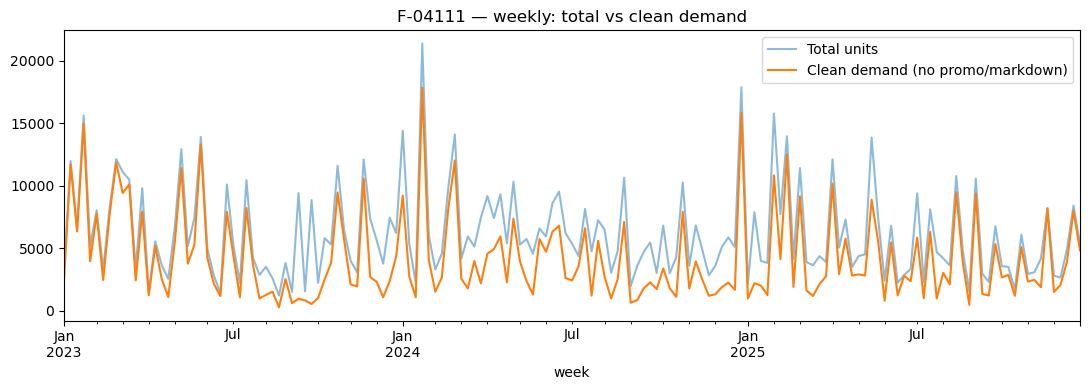

In [17]:
def tag_sales(sales_df, promo_cal, markdown_threshold=0.85):
    df = sales_df[sales_df['SOP TYPE']=='Invoice'].copy()
    df = df[df['Unit_Price_adj'] > 0]

    df['brand'] = df['ITEMDESC'].apply(extract_brand)
    df['ym']    = df['DOCDATE'].dt.to_period('M')
    df['CUSTNMBR'] = df['CUSTNMBR'].astype(str)

    # is_promo via left-merge on (customer, brand, month)
    pc = promo_cal.rename(columns={'Customer Number':'CUSTNMBR','promo_ym':'ym'}).assign(is_promo=True)
    df = df.merge(pc, on=['CUSTNMBR','brand','ym'], how='left')
    df['is_promo'] = df['is_promo'].fillna(False)

    # is_markdown via SKU median
    med = df.groupby('ITEMNMBR')['Unit_Price_adj'].median().rename('median_price')
    df = df.merge(med, left_on='ITEMNMBR', right_index=True)
    df['price_ratio'] = df['Unit_Price_adj'] / df['median_price']
    df['is_markdown'] = df['price_ratio'] < markdown_threshold

    df['is_clean_demand'] = ~(df['is_promo'] | df['is_markdown'])
    return df

tagged = tag_sales(sales, promo_cal)
print(f'Tagged invoice lines: {len(tagged):,}')
print(f'  is_promo       : {tagged["is_promo"].sum():>7,}  ({tagged["is_promo"].mean()*100:.1f}%)')
print(f'  is_markdown    : {tagged["is_markdown"].sum():>7,}  ({tagged["is_markdown"].mean()*100:.1f}%)')
print(f'  is_clean_demand: {tagged["is_clean_demand"].sum():>7,}  ({tagged["is_clean_demand"].mean()*100:.1f}%)')

print('\nPer showcase SKU:')
for sku in ['T-32206','F-04111','T-22010','T-31510']:
    s = tagged[tagged['ITEMNMBR']==sku]
    if len(s)==0: continue
    print(f'  {sku} ({str(desc_map.get(sku,""))[:40]:40s}) '
          f'lines={len(s):>6}  promo={s["is_promo"].mean()*100:5.1f}%  '
          f'mkdn={s["is_markdown"].mean()*100:5.1f}%  clean={s["is_clean_demand"].mean()*100:5.1f}%')

# Visual: clean vs total weekly units for showcase SKU
sku = 'F-04111'
s = tagged[tagged['ITEMNMBR']==sku].copy()
s['week'] = s['DOCDATE'].dt.to_period('W').dt.start_time
wk = s.groupby('week').agg(total=('QUANTITY_adj','sum'),
                            clean=('QUANTITY_adj', lambda x: x[s.loc[x.index,'is_clean_demand']].sum()))
fig, ax = plt.subplots(figsize=(11,4))
wk['total'].plot(ax=ax, label='Total units', alpha=0.5)
wk['clean'].plot(ax=ax, label='Clean demand (no promo/markdown)')
ax.set_title(f'{sku} — weekly: total vs clean demand'); ax.legend(); plt.tight_layout(); plt.show()

## Cell 13 — Diagnostic: what do the 5,416 no-brand TPR descriptions look like?

`extract_brand` substring-matches against 12 literal brand names. ~75% of TPR rows return `None`.
Before expanding the list, inspect what the unrecognized descriptions actually contain so the new
mapping is data-driven (real abbreviations), not guessed.

In [19]:
# Top no-brand descriptions and their leading tokens
no_brand = tpr[tpr['brand'].isna()].copy()
print(f'No-brand TPR rows: {len(no_brand):,} / {len(tpr):,}  ({len(no_brand)/len(tpr)*100:.1f}%)')

print('\n--- Top 30 exact no-brand descriptions ---')
print(no_brand['Item Description'].value_counts().head(30).to_string())

# Leading-token histogram (first "word" before space or dash) — usually a brand prefix
import re as _re
def first_token(s):
    if pd.isna(s): return None
    m = _re.match(r'([A-Za-z&]+)', str(s))
    return m.group(1).upper() if m else None

no_brand['prefix'] = no_brand['Item Description'].apply(first_token)
print('\n--- Top 20 leading prefixes in no-brand descriptions ---')
print(no_brand['prefix'].value_counts().head(20).to_string())

# Cross-check: what prefixes appear in the ALREADY-matched rows? That tells us the
# prefix → brand mapping we can trust.
matched = tpr[tpr['brand'].notna()].copy()
matched['prefix'] = matched['Item Description'].apply(first_token)
print('\n--- Prefix vs brand (matched rows) — trust map ---')
print(matched.groupby('prefix')['brand'].value_counts().head(30).to_string())

No-brand TPR rows: 5,416 / 7,239  (74.8%)

--- Top 30 exact no-brand descriptions ---
Item Description
BFS - 12/24 B&F Soap scan billback                    7
TBZ - 05/23 Publix TB Patch $1.5 scan bill back       6
GHC - 12/24 Ginger Honey Crystals scan billback       6
TP8 - 10/24 Publix TB Patch $1.76 scan billback       6
GHC - 04/25 Ginger Honey Crystal scan billback        6
BFS - 03/25 B&F Soap scan billback allowance          5
CFX - 05/24 CofixRX $2.00 off In-Ad coupons           5
TU8 - 01/25 TB Ultra $1.00 x 3@ + 0.16 Fee Scan       5
TM8 - 03/25 Publix TBMR $1.00 scan billback           5
TP8 - 03/25 Publix TB Patch $1.00 scan billback       5
TU8 - 03/25 Publix TB Ultra $1.25 scan billback       5
TBZ - 07/23 Publix TBMR $1.25 scan bill back          5
TP8 - 08/25 Publix TB Patch $0.39 scan billback       5
TU8 - 08/25 Publix TB Ultra $0.52 scan billback       5
TBZ - 05/23 Publix TBMR $1.25 scan bill back          5
TM8 - 07/24 Publix TBMR $1.25 scan billback           5
T